In [1]:
# Regular EDA and plotting libraries
import numpy as np  #tableaux et matrices
import pandas as pd # Permet de manipuler et d'analyser des données sous forme de dataframes, ce qui est similaire à des tableaux Excel
import matplotlib.pyplot as plt  #Permet de créer des visualisations de données, comme des graphiques et des diagrammes.
import seaborn as sns #  Permet de créer des visualisations de données plus complexes et plus attrayantes que celles fournies par matplotlib.

# We want our plots to appear in the notebook
# Afin de visualiser les graphiques dans le notebook
%matplotlib inline 

# Importation des métriques
from sklearn.metrics import accuracy_score


## Models
from sklearn.ensemble import ExtraTreesClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict #utilisés pour diviser les données en ensembles d'entraînement et de test, et pour évaluer les modèles à l'aide de la validation croisée.
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV #pour ajuster les hyperparamètres des modèles.
from sklearn.metrics import confusion_matrix, classification_report # pour évaluer les performances des modèles de classification.
from sklearn.metrics import precision_score, recall_score, f1_score #pour évaluer les performances des modèles de classification.
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+( utilisez une version antérieure de Scikit-Learn) #utilisé pour afficher la courbe ROC des modèles de classification.
from sklearn.metrics import roc_curve, roc_auc_score
# Print last updated
import time
print(f"Last updated: {time.asctime()}")

Last updated: Sat Apr 11 11:18:22 2026


In [2]:
df = pd.read_csv("heart_disease_dataset1.csv") # 'DataFrame' shortened to 'df'  # charger le jeu de données 
df.shape # (rows, columns)  # afficher sa taille

(1000, 16)

In [3]:
# Everything except target variable
X = df.drop("target", axis=1) #supprimer la variable target d'un dataframe et mettre le resultet dans X

# Target variable
y = df.target.values #pour obtenir les valeurs de la variable target dans Y

In [4]:
# Random seed for reproducibility
np.random.seed(42)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, # independent variables 
                                                    y, # dependent variable
                                                    test_size = 0.2) # percentage of data to use for test set

# diviser un ensemble de données en un ensemble d'entraînement et un ensemble de test

In [5]:
##crée un classifieur de régression logistique avec deux hyperparamètres fixés à des valeurs optimales.
# Instantiate best model with best hyperparameters (found with GridSearchCV)
clf = ExtraTreesClassifier(n_estimators=700, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=80, bootstrap=False)
clf.fit(X_train, y_train)

,n_estimators,700
,criterion,'gini'
,max_depth,80
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [6]:
# TRAIN
y_train_pred = clf.predict(X_train)
y_train_prob = clf.predict_proba(X_train)[:, 1]

# TEST
y_test_pred = clf.predict(X_test)
y_test_prob = clf.predict_proba(X_test)[:, 1]

def evaluate(name, y_true, y_pred, y_prob):
    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))


evaluate("TRAIN", y_train, y_train_pred, y_train_prob)
evaluate("TEST", y_test, y_test_pred, y_test_prob)


===== TRAIN =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0

===== TEST =====
Accuracy : 0.935
Precision: 0.948051948051948
Recall   : 0.8902439024390244
F1-score : 0.9182389937106918
ROC-AUC  : 0.9892517569243489


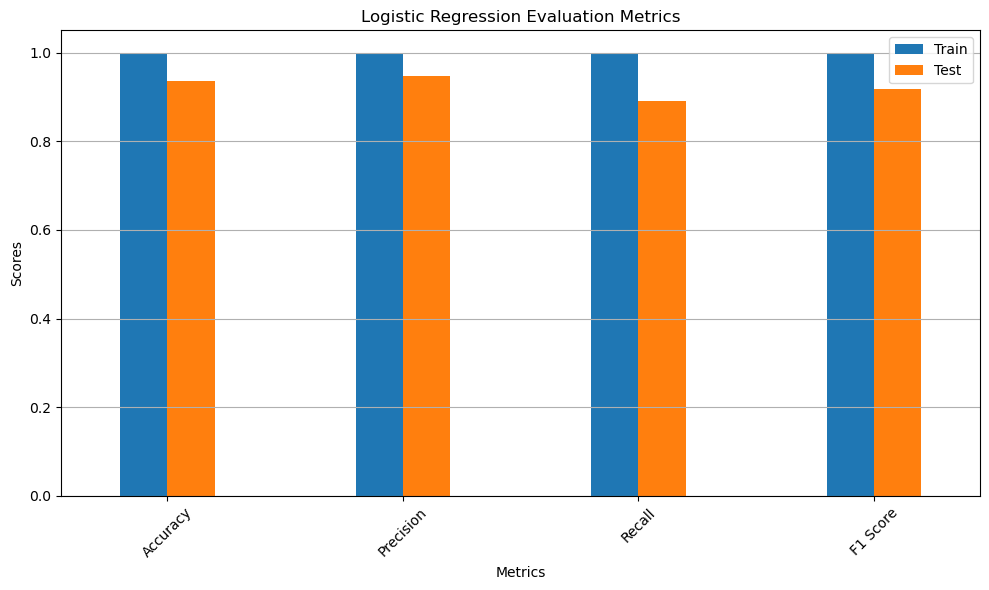

In [7]:


#  TRAIN scores
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# TEST scores
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Metrics list
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

# DataFrame
evaluation_df = pd.DataFrame({
    'Metrics': metrics,
    'Train': train_scores,
    'Test': test_scores
})

# Plot
ax = evaluation_df.plot(x='Metrics', kind='bar', figsize=(10,6), width=0.4)

plt.title('Logistic Regression Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [8]:
# Créer et entraîner le modèle de régression logistique
model = ExtraTreesClassifier(n_estimators=100, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', max_depth=10, bootstrap=True)
model.fit(X_train, y_train)

# Prédire les probabilités sur l'ensemble de test
y_probs = model.predict_proba(X_test)[:, 1]

# Prédire les classes sur l'ensemble de test
y_pred = model.predict(X_test)

# Calculer les valeurs de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculer l'AUC
auc = roc_auc_score(y_test, y_probs)

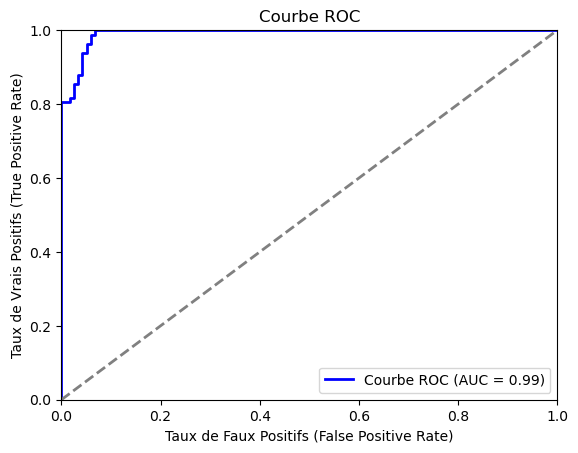

In [9]:
# Tracer la courbe ROC
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='Courbe ROC (AUC = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('Taux de Faux Positifs (False Positive Rate)')
plt.ylabel('Taux de Vrais Positifs (True Positive Rate)')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.show()

In [10]:
# Calculer la matrice de confusion
print(confusion_matrix(y_test, y_pred))

[[115   3]
 [ 14  68]]


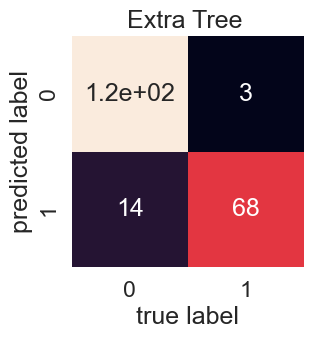

In [11]:
# Import Seaborn
import seaborn as sns
sns.set(font_scale=1.5) # Increase font size

def plot_conf_mat(y_test, y_pred):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_pred),
                     annot=True, # Annotate the boxes
                     cbar=False)
    plt.xlabel("true label")
    plt.ylabel("predicted label")
    plt.title('Extra Tree ')
plot_conf_mat(y_test, y_pred)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       118
           1       0.96      0.83      0.89        82

    accuracy                           0.92       200
   macro avg       0.92      0.90      0.91       200
weighted avg       0.92      0.92      0.91       200

